# 02 — Product Category Recommendation

Trains a scikit-learn Pipeline to predict preferred `product_category` from **social signals only**.

**Anti-leakage**
- Target = mode of transaction `category` (created in notebook 01).
- Transaction RFM / fraud aggregates share that same TX source → **excluded from `X`**.
- Training uses `data/modeling_dataset.csv` (**one row per customer**) so no customer can appear in both train and test.

**Imbalance:** `class_weight="balanced"` on `RandomForestClassifier` (inverse class frequency).

**Evaluation:** holdout metrics (incl. ROC-AUC OvR + log loss) + confusion matrix + Stratified K-Fold CV (`n_splits=2` because smallest class has 2 customers) + Markdown report under `reports/`.


In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

DATA_PATH = Path("../data/modeling_dataset.csv")
FALLBACK_PATH = Path("../data/merged_dataset.csv")
MODEL_PATH = Path("../models/product_model.pkl")
ENCODER_PATH = Path("../models/product_label_encoder.pkl")
REPORT_DIR = Path("../reports")
REPORT_PATH = REPORT_DIR / "evaluation_report.md"
CM_PATH = REPORT_DIR / "confusion_matrix.png"
TARGET = "product_category"
RANDOM_STATE = 42

# Same-source as TARGET — keep in CSV for auth, exclude from classifier inputs
TRANSACTION_LEAK_COLS = [
    "total_spent",
    "average_spent",
    "purchase_count",
    "days_since_last_purchase",
    "fraud_rate",
    "last_purchase",
]


## 1. Load & validate


In [2]:
def load_modeling_frame(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(path)
    df = pd.read_csv(path, encoding="utf-8", sep=",")
    print(f"[OK] Loaded {path.name}  shape={df.shape}")
    print(f"  dtypes:\n{df.dtypes.to_string()}")
    return df


if DATA_PATH.exists():
    df = load_modeling_frame(DATA_PATH)
    source_name = DATA_PATH.name
elif FALLBACK_PATH.exists():
    print(
        f"WARNING: {DATA_PATH} missing — falling back to {FALLBACK_PATH.name} "
        "and deduplicating to one row per customer."
    )
    df = load_modeling_frame(FALLBACK_PATH)
    source_name = FALLBACK_PATH.name
else:
    raise FileNotFoundError(
        f"Missing {DATA_PATH.resolve()}. Run notebooks/01_data_preprocessing.ipynb first."
    )

required = ["customer_id", TARGET, "engagement_score", "purchase_interest_score"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"{source_name} missing columns: {missing}")

df["customer_id"] = df["customer_id"].astype(str).str.strip().str.lower()
df[TARGET] = df[TARGET].astype(str).str.strip().str.lower()

n_rows = len(df)
if df["customer_id"].is_unique:
    model_df = df.reset_index(drop=True)
else:
    model_df = (
        df.sort_values(["customer_id", "engagement_score"], ascending=[True, False])
        .drop_duplicates(subset=["customer_id"], keep="first")
        .reset_index(drop=True)
    )
    print(f"Deduped platform-level rows {n_rows} -> {len(model_df)} customers")

assert model_df["customer_id"].is_unique
assert model_df[TARGET].notna().all()
print(f"Modeling rows: {len(model_df)} unique customers (source={source_name})")
print("Class distribution:")
print(model_df[TARGET].value_counts())
print("\nMissing values:")
print(model_df.isnull().sum())


[OK] Loaded modeling_dataset.csv  shape=(84, 14)
  dtypes:
customer_id                  object
engagement_score            float64
purchase_interest_score     float64
review_sentiment             object
average_engagement          float64
platform_count                int64
main_platform                object
total_spent                 float64
average_spent               float64
purchase_count                int64
last_purchase                object
fraud_rate                  float64
days_since_last_purchase      int64
product_category             object
Modeling rows: 84 unique customers (source=modeling_dataset.csv)
Class distribution:
product_category
other        15
finance      14
retail        9
transport     9
clothing      7
ecommerce     6
fuel          5
health        5
food          5
groceries     4
wholesale     3
travel        2
Name: count, dtype: int64

Missing values:
customer_id                 0
engagement_score            0
purchase_interest_score     0
review_sen

## 2. Features / target (no TX leakage)


In [3]:
drop_cols = [TARGET, "customer_id"] + [
    c for c in TRANSACTION_LEAK_COLS if c in model_df.columns
]
X = model_df.drop(columns=[c for c in drop_cols if c in model_df.columns])
y_raw = model_df[TARGET]

assert not any(c in X.columns for c in TRANSACTION_LEAK_COLS), X.columns.tolist()
assert len(X) == model_df["customer_id"].nunique()

label = LabelEncoder()
y = label.fit_transform(y_raw)

categorical_columns = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
numeric_columns = [c for c in X.columns if c not in categorical_columns]
print("Categorical:", categorical_columns)
print("Numeric:", numeric_columns)
print("Classes:", list(label.classes_))


Categorical: ['review_sentiment', 'main_platform']
Numeric: ['engagement_score', 'purchase_interest_score', 'average_engagement', 'platform_count']
Classes: ['clothing', 'ecommerce', 'finance', 'food', 'fuel', 'groceries', 'health', 'other', 'retail', 'transport', 'travel', 'wholesale']


## 3. Pipeline, split, train


In [4]:
numeric_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)
categorical_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_columns),
        ("cat", categorical_pipe, categorical_columns),
    ]
)

# class_weight='balanced' up-weights rare product categories (Travel/Wholesale, etc.)
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=RANDOM_STATE,
                class_weight="balanced",
            ),
        ),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

# Customer-level frame ⇒ IDs cannot overlap across splits
train_ids = set(model_df.loc[X_train.index, "customer_id"])
test_ids = set(model_df.loc[X_test.index, "customer_id"])
assert train_ids.isdisjoint(test_ids), "Customer leakage detected in holdout split"

model.fit(X_train, y_train)
print("Train size:", len(X_train), "Test size:", len(X_test))


Train size: 67 Test size: 17


## 4. Holdout evaluation


Accuracy:           0.1176
Precision (macro):  0.0278
Recall (macro):     0.0556
F1 (macro):         0.0370
F1 (weighted):      0.0784
ROC-AUC (OvR macro): 0.4879
  (OvR macro AUC over the 11 classes present in holdout (absent from holdout: ['travel']). Probabilities renormalized over present classes only.)
Log loss:           2.8647

              precision    recall  f1-score   support

    clothing       0.00      0.00      0.00         1
   ecommerce       0.00      0.00      0.00         1
     finance       0.33      0.67      0.44         3
        food       0.00      0.00      0.00         1
        fuel       0.00      0.00      0.00         1
   groceries       0.00      0.00      0.00         1
      health       0.00      0.00      0.00         1
       other       0.00      0.00      0.00         3
      retail       0.00      0.00      0.00         2
   transport       0.00      0.00      0.00         2
      travel       0.00      0.00      0.00         0
   wholesale  

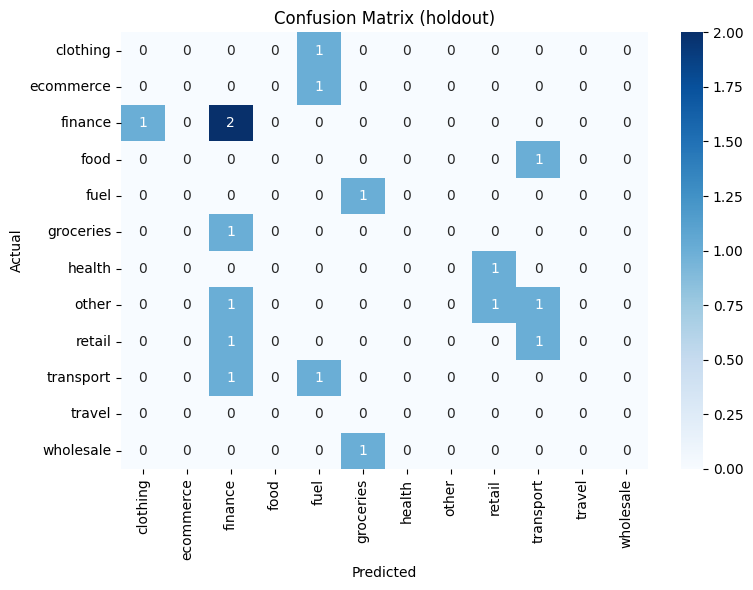

Saved confusion matrix -> D:\school\ML\Pipeline\Formative 2\multimodal-authentication\reports\confusion_matrix.png


In [5]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)
labels_idx = list(range(len(label.classes_)))

accuracy = accuracy_score(y_test, y_pred)
precision_macro = precision_score(
    y_test, y_pred, average="macro", labels=labels_idx, zero_division=0
)
recall_macro = recall_score(
    y_test, y_pred, average="macro", labels=labels_idx, zero_division=0
)
f1_macro = f1_score(
    y_test, y_pred, average="macro", labels=labels_idx, zero_division=0
)
f1_weighted = f1_score(
    y_test, y_pred, average="weighted", labels=labels_idx, zero_division=0
)

# Multiclass ROC-AUC (One-vs-Rest) + log loss from predicted probabilities
roc_auc_macro = None
roc_auc_note = ""
present_test = np.unique(y_test)
missing_in_test = sorted(set(labels_idx) - set(present_test.tolist()))
try:
    if len(present_test) < 2:
        raise ValueError("Holdout set has fewer than 2 classes.")
    # Subset + renormalize so column count matches classes present in y_test
    # (full 12-col proba fails when a rare class is absent from the holdout).
    y_proba_present = y_proba[:, present_test]
    row_sums = y_proba_present.sum(axis=1, keepdims=True)
    if np.any(row_sums <= 0):
        raise ValueError("Predicted probabilities for present classes sum to zero.")
    y_proba_present = y_proba_present / row_sums
    roc_auc_macro = float(
        roc_auc_score(
            y_test,
            y_proba_present,
            multi_class="ovr",
            average="macro",
            labels=present_test,
        )
    )
    if np.isnan(roc_auc_macro) or np.isinf(roc_auc_macro):
        raise ValueError(
            "ROC-AUC is undefined (NaN/Inf) — typically when a holdout class has "
            "too few positives/negatives for a stable OvR curve."
        )
    if missing_in_test:
        missing_names = [label.classes_[i] for i in missing_in_test]
        roc_auc_note = (
            f"OvR macro AUC over the {len(present_test)} classes present in holdout "
            f"(absent from holdout: {missing_names}). Probabilities renormalized "
            "over present classes only."
        )
except ValueError as exc:
    roc_auc_macro = None
    roc_auc_note = (
        f"ROC-AUC (OvR) not reported: {exc} "
        "With small stratified holdouts, rare classes may be missing or unpaired."
    )

log_loss_value = None
log_loss_note = ""
try:
    log_loss_value = float(log_loss(y_test, y_proba, labels=labels_idx))
    if np.isnan(log_loss_value) or np.isinf(log_loss_value):
        raise ValueError("Log loss is undefined (NaN/Inf).")
except ValueError as exc:
    log_loss_value = None
    log_loss_note = f"Log loss could not be computed: {exc}."

clf_report = classification_report(
    y_test,
    y_pred,
    labels=labels_idx,
    target_names=label.classes_,
    zero_division=0,
)

print(f"Accuracy:           {accuracy:.4f}")
print(f"Precision (macro):  {precision_macro:.4f}")
print(f"Recall (macro):     {recall_macro:.4f}")
print(f"F1 (macro):         {f1_macro:.4f}")
print(f"F1 (weighted):      {f1_weighted:.4f}")
if roc_auc_macro is not None:
    print(f"ROC-AUC (OvR macro): {roc_auc_macro:.4f}")
    if roc_auc_note:
        print(f"  ({roc_auc_note})")
else:
    print(roc_auc_note or "ROC-AUC (OvR macro): N/A")
if log_loss_value is not None:
    print(f"Log loss:           {log_loss_value:.4f}")
    if log_loss_note:
        print(f"  ({log_loss_note})")
else:
    print(log_loss_note or "Log loss: N/A")
print()
print(clf_report)

cm = confusion_matrix(y_test, y_pred, labels=labels_idx)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label.classes_,
    yticklabels=label.classes_,
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix (holdout)")
plt.tight_layout()
REPORT_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(CM_PATH, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved confusion matrix -> {CM_PATH.resolve()}")


## 5. Stratified K-Fold cross-validation

`n_splits=2` because the rarest class (travel) has only 2 customers — larger `k` cannot stratify that class.


In [6]:
cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=RANDOM_STATE)
cv_results = cross_validate(
    model,
    X,
    y,
    cv=cv,
    scoring=["accuracy", "f1_macro"],
    return_train_score=False,
)

acc_scores = cv_results["test_accuracy"]
f1_scores = cv_results["test_f1_macro"]
print("Fold accuracy:", np.round(acc_scores, 4))
print(f"Mean accuracy: {acc_scores.mean():.4f}  std: {acc_scores.std():.4f}")
print("Fold F1-macro:", np.round(f1_scores, 4))
print(f"Mean F1-macro: {f1_scores.mean():.4f}  std: {f1_scores.std():.4f}")


Fold accuracy: [0.0714 0.119 ]
Mean accuracy: 0.0952  std: 0.0238
Fold F1-macro: [0.0306 0.0849]
Mean F1-macro: 0.0578  std: 0.0271


## 6. Feature importance


In [7]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
importances = (
    pd.Series(
        model.named_steps["classifier"].feature_importances_,
        index=feature_names,
    )
    .sort_values(ascending=False)
)
print(importances.head(20).to_string())


num__purchase_interest_score      0.202501
num__average_engagement           0.199366
num__engagement_score             0.198253
num__platform_count               0.077802
cat__main_platform_linkedin       0.051051
cat__review_sentiment_positive    0.048889
cat__main_platform_instagram      0.043311
cat__main_platform_tiktok         0.041593
cat__review_sentiment_negative    0.040750
cat__main_platform_twitter        0.035641
cat__main_platform_facebook       0.030549
cat__review_sentiment_neutral     0.030296


## 7. Export evaluation report + persist model


In [8]:
REPORT_DIR.mkdir(parents=True, exist_ok=True)

def _fmt(v):
    return f"{v:.4f}" if v is not None else "N/A"

roc_auc_section = f"| ROC-AUC (OvR macro) | {_fmt(roc_auc_macro)} |\n"
if roc_auc_note:
    roc_auc_section += f"\n> {roc_auc_note}\n"
log_loss_section = f"| Log loss | {_fmt(log_loss_value)} |\n"
if log_loss_note:
    log_loss_section += f"\n> {log_loss_note}\n"

importance_md = "\n".join(
    f"| `{name}` | {val:.4f} |" for name, val in importances.head(25).items()
)

report = f"""# Product Recommendation — Evaluation Report

Generated by `notebooks/02_product_recommendation.ipynb`.

## Dataset statistics

| Item | Value |
|------|-------|
| Source file | `{source_name}` |
| Rows (customers) | {len(model_df)} |
| Features used | {X.shape[1]} |
| Classes | {len(label.classes_)} |
| Train / test size | {len(X_train)} / {len(X_test)} |
| Random state | {RANDOM_STATE} |

### Class distribution

```
{model_df[TARGET].value_counts().to_string()}
```

## Holdout metrics

| Metric | Value |
|--------|-------|
| Accuracy | {_fmt(accuracy)} |
| Precision (macro) | {_fmt(precision_macro)} |
| Recall (macro) | {_fmt(recall_macro)} |
| F1 (macro) | {_fmt(f1_macro)} |
| F1 (weighted) | {_fmt(f1_weighted)} |
{roc_auc_section}{log_loss_section}

## Cross-validation (StratifiedKFold, n_splits=2)

| Metric | Fold scores | Mean | Std |
|--------|-------------|------|-----|
| Accuracy | {np.round(acc_scores, 4).tolist()} | {acc_scores.mean():.4f} | {acc_scores.std():.4f} |
| F1 (macro) | {np.round(f1_scores, 4).tolist()} | {f1_scores.mean():.4f} | {f1_scores.std():.4f} |

## Classification report

```
{clf_report}
```

## Confusion matrix

![Confusion matrix](confusion_matrix.png)

```
{pd.DataFrame(cm, index=label.classes_, columns=label.classes_).to_string()}
```

## Feature importance (top 25)

| Feature | Importance |
|---------|------------|
{importance_md}

## Notes

- Features are **social signals only**; RFM / `fraud_rate` are excluded to avoid target leakage.
- Training frame is **one row per customer** (`modeling_dataset.csv`).
- Multiclass ROC-AUC uses One-vs-Rest (`multi_class='ovr'`, macro average).
- Log loss uses predicted class probabilities from `RandomForestClassifier.predict_proba`.
"""

REPORT_PATH.write_text(report, encoding="utf-8")
print(f"Saved evaluation report -> {REPORT_PATH.resolve()}")

MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(model, MODEL_PATH)
joblib.dump(label, ENCODER_PATH)
print(f"Saved model -> {MODEL_PATH.resolve()}")
print(f"Saved label encoder -> {ENCODER_PATH.resolve()}")


Saved evaluation report -> D:\school\ML\Pipeline\Formative 2\multimodal-authentication\reports\evaluation_report.md
Saved model -> D:\school\ML\Pipeline\Formative 2\multimodal-authentication\models\product_model.pkl
Saved label encoder -> D:\school\ML\Pipeline\Formative 2\multimodal-authentication\models\product_label_encoder.pkl
